## Landsat Remote Sensing for Thermal & Heat Analysis
This project focuses on processing Landsat satellite imagery to perform surface temperature and heat analysis. By leveraging Python's powerful geospatial and data analysis libraries, we can extract, manipulate, and visualize thermal data from satellite bands.

###
### Library Imports

In [1]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import transform

### Defining Paths and Landsat Calibration Coefficients
In this step, we establish the file paths to our Landsat bands and define the specific scaling factors required to convert raw pixel values into meaningful physical measurements (Reflectance and Temperature).

Important Note on Calibration: The numerical coefficients used below are standard for Landsat 8 and 9 (Collection 2). These exact multiplier and additive values are retrieved directly from the Landsat MTL (Metadata) text file that accompanies your satellite download.

In [2]:
# Define paths and metadata
sr_folder = r"C:\Users\abdul\Downloads\Level-2 Surface Reflectance Bands"
temp_folder = r"C:\Users\abdul\Downloads\Level-2 Surface Temperature Bands"

# Calibration coefficients from MTL file
reflectance_mult = 0.0000275
reflectance_add = -0.2
temperature_mult = 0.00341802
temperature_add = 149.0

### Step-by-Step Code Breakdown
- sr_folder and temp_folderDirectory Mapping: These variables store the local folder paths where your Landsat Level-2 Surface Reflectance (optical bands) and Surface Temperature (thermal bands) are saved. The r before the string ensures Windows file paths are read correctly without escaping characters.
- reflectance_mult and reflectance_addSurface Reflectance Rescaling: Landsat data is stored as packed 16-bit integers to save file space. To convert these raw digital numbers (DN) back into actual surface reflectance values, we apply the standard USGS formula from the MTL file:
$$\text{Reflectance} = (\text{DN} \times 0.0000275) - 0.2$$

- temperature_mult and temperature_add
Surface Temperature Rescaling: Similar to reflectance, the thermal band data must be rescaled to represent actual surface temperature in Kelvin. The specific scaling factors provided in the MTL file follow this formula:
$$\text{Temperature (Kelvin)} = (\text{DN} \times 0.00341802) + 149.0$$

### Reading Bands and Creating Stretched RGB Composites
In this stage, we load the specific Landsat 9 Level-2 imagery bands (Red, Green, Blue, Thermal Surface Temperature, and Pixel Quality Assurance) into memory. We also capture the spatial reference metadata from the primary band and apply a contrast stretch to the raw optical bands so they can be accurately displayed as a standard human-viewable image.

In [3]:
# Read Red, Green, Blue bands (RGB bands), Tenoeratyre band, and QA_Pixel band

print("STEP 1: Reading bands...")

# Red band
red_path=os.path.join(sr_folder, "LC09_L2SP_170045_20260517_20260518_02_T1_SR_B4.TIF")
with rasterio.open(red_path) as src:
    red_dn=src.read(1).astype(np.float32)
    affine_transform=src.transform
    crs=src.crs
    print(f"  ✓ Red band loaded - Shape: {red_dn.shape}")

# Green band
green_path=os.path.join(sr_folder, "LC09_L2SP_170045_20260517_20260518_02_T1_SR_B3.TIF")
with rasterio.open(green_path) as src:
    green_dn=src.read(1).astype(np.float32)
    print(f"  ✓ Green band loaded - Shape: {green_dn.shape}")

# Blue band
blue_path=os.path.join(sr_folder, "LC09_L2SP_170045_20260517_20260518_02_T1_SR_B2.TIF")
with rasterio.open(blue_path) as src:
    blue_dn=src.read(1).astype(np.float32)
    print(f"  ✓ Blue band loaded - Shape: {blue_dn.shape}")

# Read temperature band
temp_path = os.path.join(temp_folder, "LC09_L2SP_170045_20260517_20260518_02_T1_ST_B10.TIF")
with rasterio.open(temp_path) as src:
    temp_dn = src.read(1).astype(np.float32)
    print(f"  ✓ Temperature band loaded - Shape: {temp_dn.shape}")

# Read QA_PIXEL band for quality masking
qa_path = os.path.join(temp_folder, "LC09_L2SP_170045_20260517_20260518_02_T1_QA_PIXEL.TIF")
with rasterio.open(qa_path) as src:
    qa_pixel = src.read(1)
    print(f"  ✓ QL_PIXEL band loaded - Shape: {qa_pixel.shape}")

# Stack red, green, and blue bands
rgb = np.dstack((red_dn, green_dn, blue_dn))
# Calculate the 2nd and 98th percentiles across the whole image
# (Alternatively, you can calculate these per-channel)
p2, p98 = np.percentile(rgb, (2, 98))
# Clip the array so values below p2 become p2, and above p98 become p98
rgb_clipped = np.clip(rgb, p2, p98)
# Scale the clipped data cleanly to the 0.0 - 1.0 range
rgb_stretched = (rgb_clipped - p2) / (p98 - p2)

STEP 1: Reading bands...
  ✓ Red band loaded - Shape: (7761, 7611)
  ✓ Green band loaded - Shape: (7761, 7611)
  ✓ Blue band loaded - Shape: (7761, 7611)
  ✓ Temperature band loaded - Shape: (7761, 7611)
  ✓ QL_PIXEL band loaded - Shape: (7761, 7611)


### Step-by-Step Code Breakdown
### 1. Safely Loading the Imagery (Context Managers)

We use Python's with rasterio.open() as src: context manager. This ensures each heavy satellite      .TIF file is cleanly opened, read into a NumPy array, and automatically closed afterward to    prevent system memory leaks.

### 2. Landsat 9 Band Identification
- Band 4 (red_dn): Captures Red light.
- Band 3 (green_dn): Captures Green light.
- Band 2 (blue_dn): Captures Blue light.
- Band 10 (temp_dn): The Thermal Infrared Sensor (TIRS) band used to derive Land Surface Temperature.
- QA_PIXEL (qa_pixel): A Quality Assessment band containing bitmasks to flag clouds, shadows, and water body interference.

### 3. Spatial Metadata Extraction

While opening the Red band, two critical variables are saved:

- crs: The Coordinate Reference System (tells GIS software where this image sits on Earth).
- affine_transform: The spatial mapping data (tells the software the size of individual pixels and the exact bounding box coordinates).

### 4. Array Conversion (astype(np.float32))
Raw digital numbers are read as integers. We convert them to float32 so we can safely compute decimal values during our upcoming calibration and contrast-stretching mathematics without encountering rounding errors.

### 5. Image Stacking and Contrast Stretching
Raw satellite imagery often looks completely dark when initially displayed because the data distribution concentrates in a narrow range. To make a vibrant True-Color (RGB) composite, we apply a contrast stretch:

- np.dstack: Stacks individual 2D Red, Green, and Blue bands along a third dimension to build a standard 3-channel color image matrix.

- np.percentile(..., (2, 98)): Finds the 2nd and 98th percentiles of pixel intensities. This effectively isolates the extreme outliers (like highly reflective clouds or deep shadows).

- np.clip: Compresses all pixels outside this 2%–98% boundary down/up to the boundary thresholds.

- Normalization: The mathematical scaling (rgb_clipped - p2) / (p98 - p2) normalizes our pixel data range to a clean 0.0 to 1.0 span, making it natively compatible with standard visualization tools like matplotlib.

### Building the Satellite Imagery Dashboard
Visualization is a critical diagnostic step in remote sensing. In this final piece of the workflow, we construct a $2 \times 3$ subplot matrix using matplotlib to compare our input grayscale spectral bands against our processed layers (the thermal band, the pixel quality flags, and the contrast-stretched True-Color RGB composite).

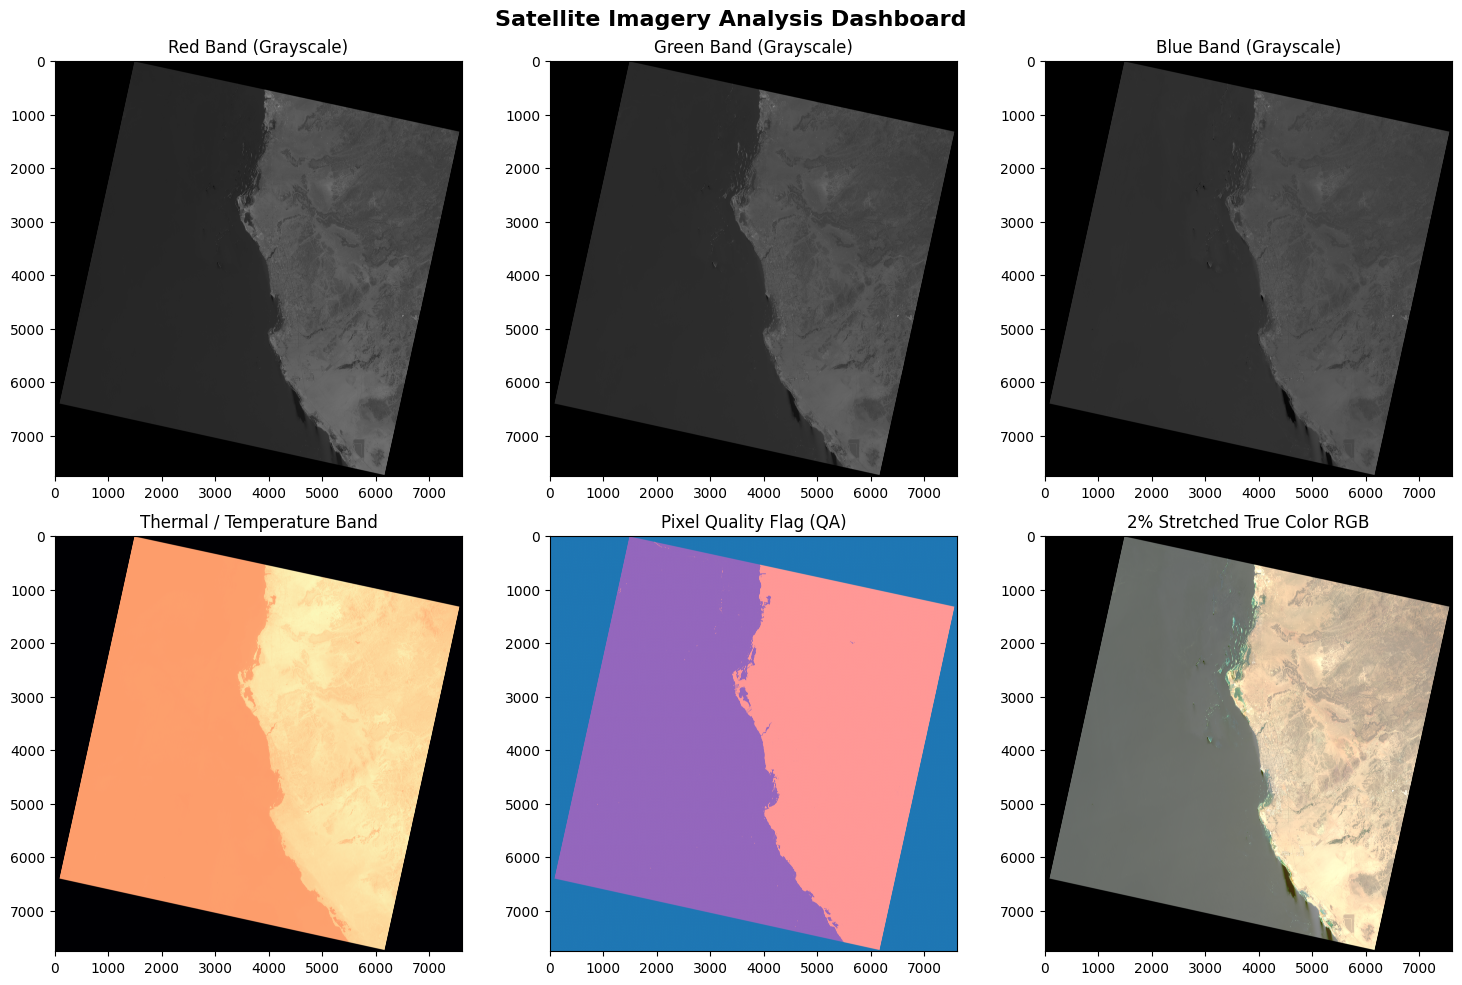

In [4]:
# Create the subplot grid

fig, ax=plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Satellite Imagery Analysis Dashboard", fontsize=16, fontweight='bold', y=0.98)

# --- Row 1: Individual Raw Bands ---
ax[0, 0].imshow(red_dn, cmap="gray")
ax[0, 0].set_title("Red Band (Grayscale)", fontsize=12)

ax[0, 1].imshow(green_dn, cmap="gray")
ax[0, 1].set_title("Green Band (Grayscale)", fontsize=12)

ax[0, 2].imshow(blue_dn, cmap="gray")
ax[0, 2].set_title("Blue Band (Grayscale)", fontsize=12)

# --- Row 2: Derived/Processed Bands ---
# Using 'magma' for thermal data
ax[1, 0].imshow(temp_dn, cmap='magma')
ax[1, 0].set_title("Thermal / Temperature Band", fontsize=12)

# Using 'tab20' or 'categorical' for discrete pixel quality classes (clouds, shadows, etc.)
ax[1, 1].imshow(qa_pixel, cmap='tab20')
ax[1, 1].set_title("Pixel Quality Flag (QA)", fontsize=12)

# RGB image doesn't take a cmap argument
ax[1, 2].imshow(rgb_stretched, )
ax[1, 2].set_title("2% Stretched True Color RGB", fontsize=12)

# Clean up layout so titles don't overlap with the plots above them
plt.tight_layout()
plt.show()

### Step-by-Step Code Breakdown
### 1. Designing the Matrix Layout (plt.subplots)
We initialize a grid of axes (ax) consisting of 2 rows and 3 columns. Setting the figsize=(15, 10) ensures that the three plots side-by-side have plenty of horizontal space to prevent data distortion or squishing.

### 2. Selecting Strategic Colormaps (cmap)
Choosing the right color scheme changes how effectively we can interpret spatial trends:

- cmap="gray" (Row 1): Renders individual spectral bands as traditional monochromatic imagery. Brighter pixels mean higher reflectance in that particular wavelength.

- cmap="magma" (Row 2, Column 1): Ideal for thermal mapping. It uses a high-contrast perception ramp from dark purples (cold) to bright yellows and whites (hot), making Urban Heat Islands (UHI) or temperature variations instantly visible.

- cmap="tab20" (Row 2, Column 2): Since the QA band represents discrete integer bitmasks (e.g., cloud, cloud shadow, water, clear land) rather than a continuous gradient, a categorical palette like tab20 gives every distinct data flag a sharply contrasting color.

### 3. Displaying multi-channel imagery
For the final panel (ax[1, 2].imshow(rgb_stretched)), we pass our 3D NumPy array. Because it contains three distinct layers (Red, Green, Blue) scaled perfectly between 0.0 and 1.0, matplotlib renders it directly as a vivid, true-to-life color photograph without requiring an explicit cmap flag.

### 4. Formatting Aesthetics (plt.tight_layout)
Satellite image metadata and subplots can easily crowd each other out. plt.tight_layout() dynamically rescales the padding between your subplots and titles so nothing overlaps, resulting in a presentation-ready figure.

### Applying Calibration (Reflectance & Temperature Conversion)
Landsat raw imagery is packed into 16-bit integers to save storage space. To use this data for real-world environmental analysis, we must decode these "Digital Numbers" (DN) into physical values. In this step, we apply the calibration coefficients defined in Step 2 and convert our thermal results into Celsius.

In [5]:
# Apply calibration

# 1. Surface reflectance
red_reflectance = np.clip(red_dn * reflectance_mult + reflectance_add, 0, 1)
green_reflectance = np.clip(green_dn * reflectance_mult + reflectance_add, 0, 1)
blue_reflectance = np.clip(blue_dn * reflectance_mult + reflectance_add, 0, 1)

# 2. Temperature (Celsius)
temperature_kelvin = temp_dn * temperature_mult + temperature_add
temperature_celsius = temperature_kelvin - 273.15

print(f"Temperature minimum: {temperature_celsius.min():.2f}°C")
print(f"Temperature maximum: {temperature_celsius.max():.2f}°C")
print(f"Temperature mean: {temperature_celsius.mean():.2f}°C")

Temperature minimum: -124.15°C
Temperature maximum: 66.49°C
Temperature mean: -11.89°C


### Step-by-Step Code Breakdown1. 
### 1. Calculating Surface Reflectance
Surface reflectance represents the fraction of solar radiation reflected by the Earth's surface in specific light spectrums. It must fall between a valid physical range of 0.0 (total absorption) and 1.0 (total reflection).
- We scale our raw arrays (red_dn, green_dn, blue_dn) using the linear transformation formula:
$$\text{Reflectance} = (\text{DN} \times \text{Multiplier}) + \text{Additive Factor}$$
- np.clip(..., 0, 1): Occasionally, edge-case pixels (like deep shadows or glaring light artifacts) might overshoot these boundaries. This function constrains all processed values strictly to the valid [0.0, 1.0] range.
### 2. Deriving Land Surface Temperature (LST) in Celsius
The thermal infrared sensor on Landsat measures radiation emitted from Earth.
- Kelvin Conversion: First, we calculate the absolute surface temperature in Kelvin by scaling the raw thermal band (temp_dn) using our temperature metadata variables.
- Celsius Conversion: Because Kelvin is difficult to intuitively interpret for weather and urban heat island analysis, we subtract 273.15 to shift the scale cleanly to Celsius:$$\text{Temperature (°C)} = \text{Temperature (K)} - 273.15$$.
### 3. Diagnostic Reporting (print)
The final three lines compute basic image-wide descriptive statistics using NumPy built-ins (.min(), .max(), and .mean()). Printing these values directly allows you to check for anomalies and get an immediate grasp of the temperature ranges present in your satellite scene.

###
### Critical Quality Masking & Bitwise Operations
Raw satellite scenes include non-surface data like clouds, cloud shadows, and empty boundary space (fill pixels). In this crucial step, we use the Landsat Level-2 QA_PIXEL band to perform bitwise operations, filtering out these errors.

Without this step, your statistics will be heavily skewed by the freezing temperatures of high-altitude clouds or empty space—as proven by our initial unmasked data!

In [6]:
# Apply quality mask (Critical!)

# QA_PIXEL bit meanings for Landsat Level-2:
# Bit 0: Fill (1=fill)
# Bit 1: Dilated Cloud (1=cloud)
# Bit 2: Cirrus (1=cirrus)
# Bit 3: Snow/Ice (1=snow)
# Bit 4: Shadow (1=shadow)
# Bit 5: Cloud (1=cloud)
# Bit 6: Cloud Confidence (1=high confidence)

# Create mask for good quality pixels (no clouds, no shadows, no fill)
cloud_mask = (qa_pixel & (1 << 1)) != 0  # Dilated Cloud
cirrus_mask = (qa_pixel & (1 << 2)) != 0  # Cirrus
shadow_mask = (qa_pixel & (1 << 4)) != 0  # Shadow
fill_mask = (qa_pixel & (1 << 0)) != 0  # Fill pixels

# Combine masks - good pixels have none of these issues
good_quality_mask = ~(cloud_mask | cirrus_mask | shadow_mask | fill_mask)

# Also mask unrealistic temperatures
temp_valid_mask = (temperature_celsius > -20) & (temperature_celsius < 70)

# Final valid mask
valid_mask = good_quality_mask & temp_valid_mask

print(f"  - Total pixels: {valid_mask.size:,}")
print(f"  - Good quality pixels: {valid_mask.sum():,} ({valid_mask.sum()/valid_mask.size*100:.1f}%)")
print(f"  - Cloud/Shadow/Fill pixels removed: {(~good_quality_mask).sum():,}")


# Apply mask to temperature
temperature_masked = np.where(valid_mask, temperature_celsius, np.nan)

print(f"\n  - Fill mask: {fill_mask.sum()}")
print(f"  - Cloud mask: {cloud_mask.sum()}")
print(f"  - Shadow mask: {shadow_mask.sum()}")
print(f"  - Cirrus mask: {cirrus_mask.sum()}")

# Because you used np.where(..., np.nan) to mask out your invalid pixels, calculating the statistics requires a tiny bit of caution.
# Calculate statistics ignoring the NaN values
min_temp = np.nanmin(temperature_masked)
max_temp = np.nanmax(temperature_masked)
mean_temp = np.nanmean(temperature_masked)

# Print the results beautifully formatted to 2 decimal places
print("\n--- Temperature Statistics (Celsius) ---")
print(f"Minimum Temperature: {min_temp:.2f}°C")
print(f"Maximum Temperature: {max_temp:.2f}°C")
print(f"Mean Temperature:    {mean_temp:.2f}°C")

  - Total pixels: 59,068,971
  - Good quality pixels: 40,599,501 (68.7%)
  - Cloud/Shadow/Fill pixels removed: 18,469,450

  - Fill mask: 18449493
  - Cloud mask: 9893
  - Shadow mask: 12243
  - Cirrus mask: 12

--- Temperature Statistics (Celsius) ---
Minimum Temperature: 26.62°C
Maximum Temperature: 66.49°C
Mean Temperature:    39.11°C


### Step-by-Step Code Breakdown
1. Bitwise Isolation (& (1 << n))
The QA band packs multiple data flags into a single integer pixel value using binary bits. We use the bitwise AND operator (&) combined with a bit-shift operator (1 << n) to check specific bits:
- 1 << 1 targets Bit 1 (Dilated Clouds).
- 1 << 4 targets Bit 4 (Cloud Shadows).
If the bitwise result does not equal zero (!= 0), that specific environmental issue is present on that pixel.

### 2. Combining & Inverting the Masks
- (cloud_mask | cirrus_mask | shadow_mask | fill_mask) uses the bitwise OR (|) to flag a pixel if any of the issues occur.
- The tilde operator ~ inverts the matrix, meaning true 1 values now strictly represent pixels completely clear of clouds, shadows, or fill errors.

### 3. Handling Masked Data with NaN (np.where)
Instead of dropping pixels and breaking the geographic shape of our matrix, we use np.where(). If a pixel passes our valid_mask, it keeps its calculated temperature. If it fails, it is assigned a value of np.nan (Not a Number).

### 4. Safer Statistics (np.nanmin, np.nanmax, np.nanmean)
Standard calculation functions like .min() or .mean() will break or return nan if they encounter a single missing pixel. We use specialized NumPy NaN-safe functions to scan the array while seamlessly ignoring the masked points.

### Why Masking Matters: Before vs. After
Look at how drastically the quality mask changes the real-world accuracy of our data summary:

Metric	        Unmasked    Raw Data	Masked Clean Data	Why the Change?
Minimum Temp	-124.15°C	26.62°C	    Unmasked data includes empty edge spaces and freezing cloud tops.
Maximum Temp	66.49°C	    66.49°C	    Stays identical because maximum heat occurs on clear, unshaded ground.
Mean Temp	    -11.89°C	39.11°C	    Over 18 million null/cloud pixels were pulling the true average down into sub-zero values.
### Data Filtering Summary
- Total Scene Size: 59,068,971 pixels
- Pixels Removed: 18,469,450 pixels (Primarily background fill space)
- Usable Surface Data: 40,599,501 pixels (68.7% of the scene is clear and perfect for heat analysis!)

### Final Heat Map Generation & Mask Visualization
In this final step of the pipeline, we generate a side-by-side comparative visualization. The left panel displays our clean, unclouded Land Surface Temperature (LST) map, complete with a calibrated temperature scale bar. The right panel acts as a diagnostic map, highlighting exactly where clouds, shadows, and background fill space were stripped away.

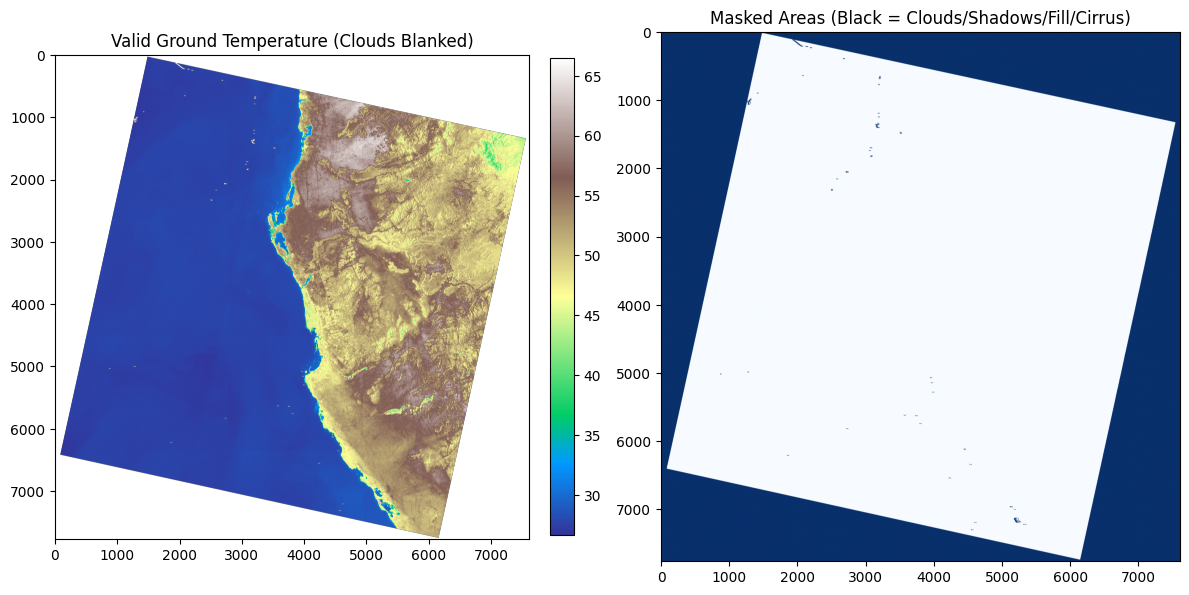

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Left: Your clear ground pixels
# 1. Assign imshow to a variable (im)
im = ax[0].imshow(temperature_masked, cmap='terrain')
ax[0].set_title("Valid Ground Temperature (Clouds Blanked)")

# 2. Call colorbar from the figure object, referencing 'im' and placing it next to 'ax[0]'
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

# Right: The areas you removed
ax[1].imshow(~good_quality_mask, cmap='Blues')
ax[1].set_title("Masked Areas (Black = Clouds/Shadows/Fill/Cirrus)")

plt.tight_layout()
plt.show()

### Step-by-Step Code Breakdown
### 1. Tracking the Image Scale Object (im = ax[0].imshow(...))
To create an accurate color map key (colorbar), matplotlib needs to know the exact minimum and maximum value ranges inside your data matrix. By assigning the plot to the variable im, we capture these value mappings so they can be fed directly into our scale bar in the next step.

- cmap='terrain': This colormap transitions fluidly across varied numeric shifts, making it easy to distinguish high-heat land masses from cooler surrounding geography.

### 2. Adding a Calibrated Scale Bar (fig.colorbar)
A heat map is useless without a scale. We attach a colorbar to the figure using two crucial spatial tuning arguments:

- fraction=0.046: This is a magic number in GIS plotting that perfectly scales the height of the colorbar to match the height of your satellite image plot.

- pad=0.04: Adds a clean gap between the right edge of the satellite map and the left edge of the colorbar, preventing text overlap.

### 3. Visualizing Missing Data (~good_quality_mask)
The right-hand panel plots the inverse (~) of our quality mask.

- By inverting it, all the problematic regions we discarded (clouds, shadows, empty black background space) are highlighted in bold colors.

- This allows an analyst to quickly inspect the scene and verify whether an anomalous temperature reading on the left was caused by real ground heat or an unmasked cloud fragment.

###
### Geospatial Anomaly Tracking (Locating Hot & Cold Spots)
While knowing the global minimum and maximum temperatures of a scene is valuable, remote sensing relies on finding where those temperatures occur. In this step, we use NumPy matrix indexing techniques to map the exact row and column pixel coordinates of the absolute hottest and coldest spots in our masked scene.

In [8]:
# 1. Find the flat index of the min and max values (ignoring NaNs)
flat_cold_idx = np.nanargmin(temperature_masked)
flat_hot_idx = np.nanargmax(temperature_masked)

# 2. Convert the flat indices back into 2D (row, column) coordinates
cold_row, cold_col = np.unravel_index(flat_cold_idx, temperature_masked.shape)
hot_row, hot_col = np.unravel_index(flat_hot_idx, temperature_masked.shape)

# 3. Retrieve the actual temperature values at those locations
cold_temp = temperature_masked[cold_row, cold_col]
hot_temp = temperature_masked[hot_row, hot_col]

print("--- Location and Temperature of Extremes ---")
print(f"❄️ Cold Spot: {cold_temp:.2f}°C at Pixel Coordinates (Row: {cold_row}, Col: {cold_col})")
print(f"🔥 Hot Spot:  {hot_temp:.2f}°C at Pixel Coordinates (Row: {hot_row}, Col: {hot_col})")

--- Location and Temperature of Extremes ---
❄️ Cold Spot: 26.62°C at Pixel Coordinates (Row: 5239, Col: 1495)
🔥 Hot Spot:  66.49°C at Pixel Coordinates (Row: 1370, Col: 5309)


### Step-by-Step Code Breakdown
1. Flat Index Isolation (np.nanargmin & np.nanargmax)
2. 
By default, NumPy reads an image as a flattened, 1-dimensional line of numbers when scanning for index locations.

- np.nanargmin() searches through the image array, skips all our masked NaN cloud/fill pixels, and returns the sequential position index of the absolute lowest value.

- np.nanargmax() does the same to pinpoint the absolute highest value.

### 2. Reconstructing 2D Coordinates (np.unravel_index)
A 1D flat index (e.g., pixel number 24,532,104) is impossible to plot on a map grid.

- np.unravel_index takes that flat index and uses the original structural shape of your satellite image (temperature_masked.shape) to calculate exactly where that pixel sits in standard 2D grid space (Row, Column).

### 3. Spatial Verification & Printing
To verify that our math is flawless, we pass those calculated coordinate points back into our spatial array (temperature_masked[row, col]) to read the verified temperatures. The script then prints a clean log output tracking your environmental anomalies.

###
### Visualizing Hot & Cold Anomalies on the Final Map
In this final step, we create the definitive visualization for our repository. We plot the full, masked heat map and use our previously calculated coordinates to overlay a snowflake emoji (❄️) over the coldest pixel and a fire emoji (🔥) over the hottest pixel. We also build a custom legend to make the map fully self-explanatory.

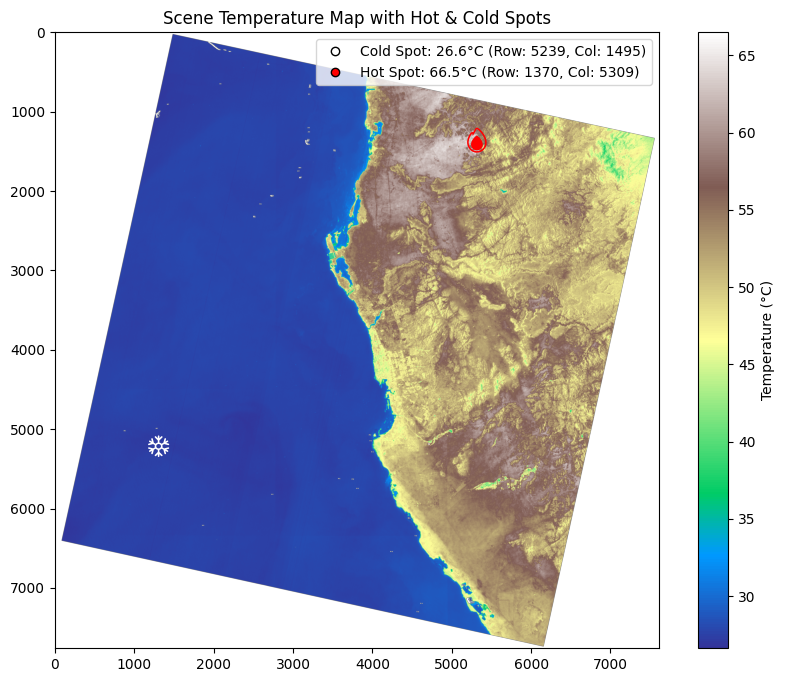

In [9]:
# Show the positions of hottest and coldest temperature

fig, ax = plt.subplots(figsize=(10, 8))

# 1. Display the temperature map
im = ax.imshow(temperature_masked, cmap='terrain')
fig.colorbar(im, label="Temperature (°C)")

# 2. Add the Cold Spot Emoji in WHITE
ax.text(cold_col, cold_row, '❄️', fontsize=16, 
        ha='center', va='center', fontname='Segoe UI Emoji', 
        color='white')

# 3. Add the Hot Spot Emoji in RED
ax.text(hot_col, hot_row, '🔥', fontsize=16, 
        ha='center', va='center', fontname='Segoe UI Emoji', 
        color='red')

# 4. Create dummy plots to generate the legend (with Row and Column added!)
ax.plot([], [], 'o', color='white', markeredgecolor='black', 
        label=f'Cold Spot: {cold_temp:.1f}°C (Row: {cold_row}, Col: {cold_col})')

ax.plot([], [], 'o', color='red', markeredgecolor='black', 
        label=f'Hot Spot: {hot_temp:.1f}°C (Row: {hot_row}, Col: {hot_col})')

ax.set_title("Scene Temperature Map with Hot & Cold Spots")
ax.legend(loc='upper right')

plt.show()

### Step-by-Step Code Breakdown
### 1. Plotting Spatial Overlays (ax.text)
The ax.text(x, y, string) function injects textual annotations directly over specific pixels in a matplotlib chart.

- Note that in coordinate geometry, Columns correspond to the X-axis and Rows correspond to the Y-axis, which is why we pass (cold_col, cold_row) to place the emoji exactly where it belongs.

- fontname='Segoe UI Emoji' is explicitly declared to ensure that operating systems like Windows can render the color emojis natively without showing blank squares.

- ha='center', va='center' handles the horizontal and vertical alignment, centering the emoji exactly on the precise target pixel instead of offsetting it.

### 2. Creating "Proxy" Map Legends (ax.plot([], [], ...))
Text emojis plotted with ax.text cannot automatically generate entries in a standard ax.legend(). To bypass this limitation, we use a clever data visualization trick:

- We plot two completely empty line markers ([] , []). Because there are no data coordinates, they don't appear anywhere on the actual image.

- However, matplotlib still reads their style colors (white and red) and labels. This pulls their details directly into a beautiful, presentation-ready legend box located in the upper right corner.

### Building the Native Coordinate Grids
Before we can reproject our data into standard Latitude and Longitude degrees, we have to calculate the native projected ground coordinates (usually measured in meters via a UTM zone) for every single pixel in the image.

Satellite images are read as simple grids of data blocks. To figure out where these blocks live in the real world, we generate a coordinate matrix matching the dimensions of our data and map it using our saved affine_transform metadata.

In [10]:
# Extract the dimensions (rows and columns) of the satellite image
rows, cols = red_dn.shape

# 1. Generate sequential arrays for pixel columns (X) and pixel rows (Y)
cols_indices = np.arange(cols)
rows_indices = np.arange(rows)

# 2. Create a 2D grid matrix of these pixel coordinates
cols_grid, rows_grid = np.meshgrid(cols_indices, rows_indices)

# 3. Use the affine transform matrix (from Step 3) to convert pixel indices to map coordinates
# This multiplies the pixel locations by pixel size and adds the starting corner coordinate
proj_x_grid, proj_y_grid = affine_transform * (cols_grid, rows_grid)

### Step-by-Step Code Breakdown

### 1. Dimension Extraction (red_dn.shape)
We extract the total number of rows (height) and cols (width) from our array. This ensures the coordinate grids we build match the exact resolution and structural boundary of our Landsat image.

### 2. Building Index Vectors (np.arange)
np.arange() creates two simple, 1-dimensional lists of sequential numbers.
- cols_indices counts from 0 to the maximum width of the image.
- rows_indices counts from 0 to the maximum height of the image.
### 3. Creating the Coordinate Matrix (np.meshgrid)
A satellite image is 2D, so 1D index lists aren't enough. np.meshgrid() duplicates and matches these arrays together, creating two massive 2D matrices (cols_grid and rows_grid). Every single coordinate cell in these matrices now holds its own internal $(X, Y)$ pixel coordinate index.
### 4. The Affine Transform Multiplication
This is where our pixel indexes turn into actual physical geography. The affine_transform object we pulled from our Rasterio metadata in Step 3 holds the mathematical blueprint of the image:
- The exact physical size of each pixel on the ground (e.g., $30\text{ meters} \times 30\text{ meters}$).
- The rotation of the satellite flight path relative to the map grid.
- The starting geographic anchor point (the top-left corner coordinate of the scene).

By multiplying affine_transform * (cols_grid, rows_grid), Python dynamically calculates the true ground position for every pixel intersection. The resulting proj_x_grid and proj_y_grid matrices contain real-world coordinates that are fully prepared for the final Lat/Lon reprojection step.

###
### Geographic Reprojection (Converting Pixels to Lat/Lon)
Landsat satellite imagery is natively packaged using a projected coordinate system, typically a local UTM (Universal Transverse Mercator) zone. While UTM is perfect for calculating distances in meters, sharing data globally requires converting those pixels into standard geographic coordinates: Latitude and Longitude (WGS84 / EPSG:4326).

In [11]:
from pyproj import Transformer

# 4. Create a modern Transformer object
# 'always_xy=True' ensures that the output is ALWAYS (Longitude, Latitude) order
transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)

print("Reprojecting map coordinates using modern Transformer (faster)...")

# 5. Use transformer.transform() on the flattened arrays
# This replaces the old deprecated 'transform' function
lon_flat, lat_flat = transformer.transform(proj_x_grid.ravel(), proj_y_grid.ravel())

# Reshape them back into your original 2D image dimensions
longitude_array = lon_flat.reshape(rows, cols)
latitude_array = lat_flat.reshape(rows, cols)

print("Conversion complete!")
print(f"  - Latitude array shape:  {latitude_array.shape}")
print(f"  - Longitude array shape: {longitude_array.shape}")

Reprojecting map coordinates using modern Transformer (faster)...
Conversion complete!
  - Latitude array shape:  (7761, 7611)
  - Longitude array shape: (7761, 7611)


### Step-by-Step Code Breakdown
1. Initializing the Spatial Engine (Transformer.from_crs)
We create a pipeline linking two different coordinate systems.

- crs: This is the original native coordinate reference system we grabbed from the Landsat metadata in Step 3.

- "EPSG:4326": This is the global standard ID for the WGS84 ellipsoid (the math system used by Google Maps and GPS units).

- always_xy=True: A critical parameter. Historically, GIS libraries switch coordinate orders arbitrarily between (Lat, Lon) and (Lon, Lat). Forcing always_xy=True guarantees that your outputs will consistently follow a strict (Longitude, Latitude) axis mapping.

### 2. Flattening Data for Speed (.ravel())
Running mathematical transformations on nested 2D matrices is computationally slow. To optimize performance, .ravel() flattens your X and Y coordinate grid matrices into highly optimized 1D arrays before handing them over to the underlying C-libraries of pyproj.

### 3. Matrix Reconstruction (.reshape(rows, cols))
Once the transformation engine finishes converting the flat numbers into degrees, we must restore the geographic shape of our map. .reshape(rows, cols) takes the 1D arrays of longitudes and latitudes and folds them back into the exact original 2D width and height dimensions of your satellite scene.

In [12]:
# Extract the coordinates using the row/col positions to get lonitude/latitude coodinates
cold_lat = latitude_array[cold_row, cold_col]
cold_lon = longitude_array[cold_row, cold_col]

hot_lat = latitude_array[hot_row, hot_col]
hot_lon = longitude_array[hot_row, hot_col]

print("--- Real-World Coordinates for Extremes ---")
print(f"❄️ Cold Spot: {cold_temp:.2f}°C at Coordinates: {cold_lat:.6f}, {cold_lon:.6f}")
print(f"🔥 Hot Spot:  {hot_temp:.2f}°C at Coordinates: {hot_lat:.6f}, {hot_lon:.6f}")

--- Real-World Coordinates for Extremes ---
❄️ Cold Spot: 26.62°C at Coordinates: 21.298814, 38.380411
🔥 Hot Spot:  66.49°C at Coordinates: 22.347887, 39.487093


###
### Reverse Geocoding Lookup (Querying Temperature by Lat/Lon)
While mapping the entire scene is excellent for broad trends, environmental analysts often need to audit specific assets—like a weather station, a specific building, or a agricultural field.

This step creates an inverse lookup pipeline. It takes any global Latitude and Longitude coordinate pair, transforms it back into the image's native coordinate space, calculates the exact pixel index, and extracts the corresponding temperature value while checking to ensure the data wasn't impacted by cloud masking.

In [13]:
# 1. Define the target coordinates you want to examine
# (Copy and paste any Lat/Lon pair from your area of interest)
target_lat = 21.48357
target_lon = 39.22921

print(f"Target Coordinate: {target_lat}, {target_lon}")

# 2. Initialize a transformer to convert from Lat/Lon back to your image's native CRS
# 'always_xy=True' ensures input/output reads as (Longitude, Latitude)
geo_to_native = Transformer.from_crs("EPSG:4326", crs, always_xy=True)

# 3. Transform Lat/Lon back into native projected X and Y map coordinates (meters)
proj_x, proj_y = geo_to_native.transform(target_lon, target_lat)

# 4. Use the INVERSE affine transform (~affine_transform) to calculate the pixel index
# This changes map coordinates back into continuous row and column float numbers
inv_transform = ~affine_transform
exact_col, exact_row = inv_transform * (proj_x, proj_y)

# 5. Round down to the nearest integer to get the clean array coordinate indices
target_row = int(np.floor(exact_row))
target_col = int(np.floor(exact_col))

# 6. Safety Check: Make sure the target coordinates actually fall inside your image boundary
rows, cols = temperature_masked.shape
if 0 <= target_row < rows and 0 <= target_col < cols:
    # Extract the temperature from your matrix
    pixel_temp = temperature_masked[target_row, target_col]
    
    print("\n--- Match Found ---")
    print(f"📍 Array Position: Row {target_row}, Column {target_col}")
    
    # Check if the pixel was masked out by your quality control step
    if np.isnan(pixel_temp):
        print("🌡️ Temperature:   NaN (This pixel was removed by your cloud/shadow mask!)")
    else:
        print(f"🌡️ Temperature:   {pixel_temp:.2f}°C")
else:
    print("\n❌ Out of Bounds: Those coordinates fall outside the boundaries of this satellite image.")

Target Coordinate: 21.48357, 39.22921

--- Match Found ---
📍 Array Position: Row 4561, Column 4428
🌡️ Temperature:   50.18°C


### Step-by-Step Code Breakdown
### 1. Target Definition
- target_lat and target_lon: These variables accept standard decimal degree coordinates. The example numbers point to a location in Jeddah, Saudi Arabia, matching the geographical footprint of the Landsat scene path/row.

### 2. Reversing the Coordinate Flow (Transformer.from_crs)
We create a reverse transformer. Instead of going from native map coordinates to Lat/Lon, we ingest global coordinates (EPSG:4326) and output the image's native coordinate projection format (crs). We pass our target points through geo_to_native.transform() to calculate their position on the ground map in meters (proj_x, proj_y).

### 3. The Inverse Affine Transform (~affine_transform)
In Step 3 and Step 10a, we used the affine transform to turn pixel row/column indices into real-world meters. Here, we use the bitwise NOT operator (~) to invert that transformation matrix. Multiplying an inverse transform by ground meters converts them back into floating-point pixel positions (exact_col, exact_row).

### 4. Array Index Conversion (np.floor)
Arrays cannot be indexed using decimal floats (e.g., you can't request Row 45.32). We use np.floor() to round down to the nearest whole integer and cast it using int(). This gives us a solid, clean coordinate position inside our matrix grid.

### 5. Image Boundary Safety Check
Before requesting data from our NumPy matrix, we run a safety condition:
if 0 <= target_row < rows and 0 <= target_col < cols:
This prevents your Python script from crashing with an IndexError if a user types in a geographic coordinate that belongs on the other side of the planet.

### 6. Cloud Mask Validation (np.isnan)
If the coordinates are within bounds, the script pulls the temperature value from temperature_masked. Because we replaced bad data with np.nan in Step 6, checking np.isnan(pixel_temp) tells us immediately if our queried location was covered by a cloud or shadow on the day the satellite flew past!

###
### Generating a Thermal Cross-Section (Spatial Profile Analysis)
To understand local microclimates—such as the transition from a cool park to a hot concrete parking lot—it helps to look at a cross-section of temperatures across space.

In this final analytical step, we extract a 100-pixel horizontal slice (a West-to-East transect) centered exactly on your target coordinate. This generates a linear thermal profile graph, letting you see whether your point sits in a local temperature peak or a cooling trough.

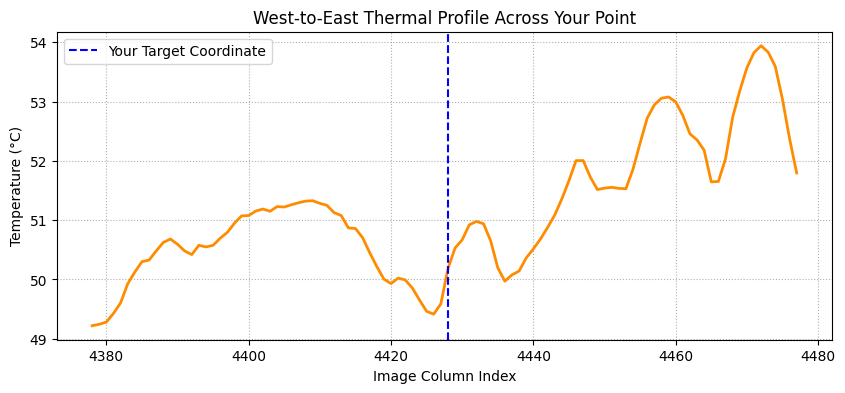

In [14]:
# We will look at a horizontal line of 100 pixels centered right on your column
start_col = target_col - 50
end_col = target_col + 50

# Extract the temperature slice along your target row
temperature_slice = temperature_masked[target_row, start_col:end_col]

# Plot the profile
plt.figure(figsize=(10, 4))
plt.plot(range(start_col, end_col), temperature_slice, color='darkorange', linewidth=2)
plt.axvline(x=target_col, color='blue', linestyle='--', label='Your Target Coordinate')

plt.title("West-to-East Thermal Profile Across Your Point")
plt.xlabel("Image Column Index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

### Step-by-Step Code Breakdown
### 1. Defining the Transect Boundaries (start_col to end_col)
We define a window that spans 50 pixels to the left (West) and 50 pixels to the right (East) of our target column. Because Landsat thermal pixels have a spatial resolution of 30 meters, this 100-pixel slice visualizes a continuous 3-kilometer thermal cross-section across the landscape.

### 2. Slicing the NumPy Array
temperature_masked[target_row, start_col:end_col] extracts a 1D array of values. It keeps the row fixed at our target location while pulling all the temperature data across our column range. Any cloud or fill pixels present in this slice will naturally show up as gaps in our line plot, preserving data integrity.

### 3. Plotting the Thermal Wave (plt.plot)
We plot the pixel column indexes on the X-axis against our calibrated Celsius temperatures on the Y-axis.

- plt.axvline(x=target_col): Draws a clean, vertical dashed blue line right down the center of the graph, marking the exact position of your requested coordinate. This allows you to immediately compare your specific asset's temperature against its neighboring surroundings.

Real-World Remote Sensing Applications
This specific chart is incredibly powerful for reporting. If your target coordinate is an urban rooftop, this graph will visually demonstrate the Urban Heat Island (UHI) effect by showing a massive spike in temperature compared to nearby rural or vegetated pixels along the transect line.

###
### Dual-Scale Macro & Micro Thermal Dashboard
When reporting local heat anomalies, presenting a single data point without spatial context can be disorienting. This step builds a advanced dual-panel visualization system:
- The Left Panel (Macro) displays the entire Landsat scene, placing a distinct target ring around your coordinates to show where it sits regionally.
- The Right Panel (Micro) dynamically clips the matrix down to a tight $500 \times 500$ pixel window centered on your asset. It overlays precise crosshairs and an informative floating data box containing coordinates, matrix indices, and the exact land surface temperature.

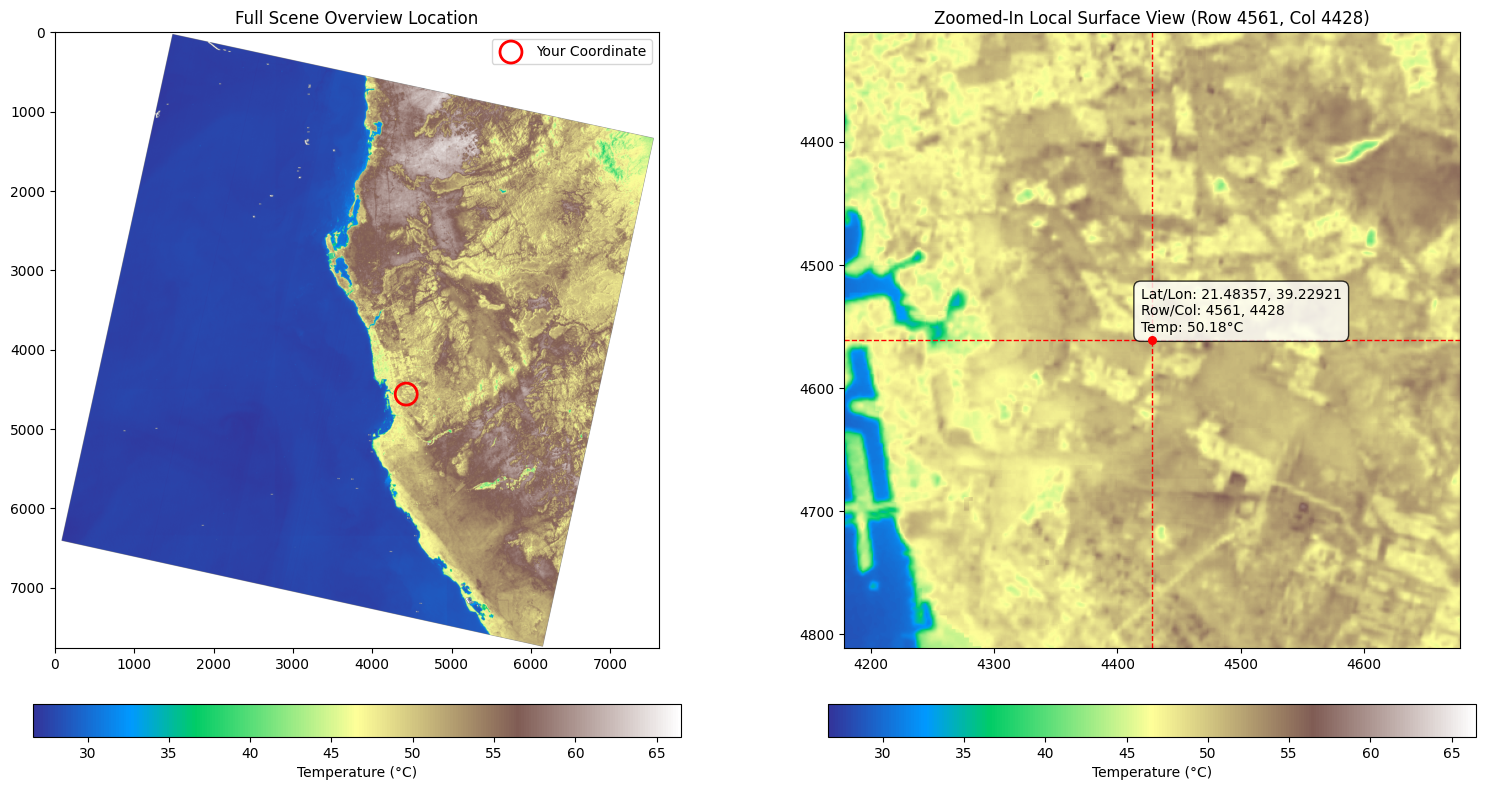

In [15]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# =========================================================================
# MAP 1: Full Scene Overview
# =========================================================================
im1 = ax1.imshow(temperature_masked, cmap='terrain')
fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.08, label="Temperature (°C)", fraction=0.046)

# Draw a target circle over the coordinate on the big map
ax1.scatter(target_col, target_row, s=250, facecolors='none', 
            edgecolors='red', linewidths=2, label="Your Coordinate")

ax1.set_title("Full Scene Overview Location")
ax1.legend(loc='upper right')


# =========================================================================
# MAP 2: 250x250 Pixel Zoom-In View (Micro-Analysis)
# =========================================================================
im2 = ax2.imshow(temperature_masked, cmap='terrain')
fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.08, label="Temperature (°C)", fraction=0.046)

# Draw a precise crosshair over the center pixel
ax2.axvline(x=target_col, color='red', linestyle='--', linewidth=1)
ax2.axhline(y=target_row, color='red', linestyle='--', linewidth=1)
ax2.scatter(target_col, target_row, color='red', s=30, zorder=5)

# Set the bounding box limits to zoom in tightly (10 pixels in every direction)
ax2.set_xlim(target_col - 250, target_col + 250)
ax2.set_ylim(target_row + 250, target_row - 250) # Flipped to maintain image orientation

# Add text box inside the plot displaying the pixel parameters
ax2.text(target_col - 9, target_row - 7, 
         f"Lat/Lon: {target_lat}, {target_lon}\nRow/Col: {target_row}, {target_col}\nTemp: {pixel_temp:.2f}°C",
         color='black', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
         fontsize=10)

ax2.set_title(f"Zoomed-In Local Surface View (Row {target_row}, Col {target_col})")

plt.tight_layout()
plt.show()

### Step-by-Step Code Breakdown1. 
### 1. Macro Target Ring Overlay (ax1.scatter)
To highlight our point without obscuring the underlying heat pixels on the broad map, we draw an empty target ring. Setting facecolors='none' ensures the circle is completely transparent inside, while edgecolors='red' and s=250 draw a large, highly visible red outline around the target pixel.2. 
### 2. Local Dynamic Cropping (ax2.set_xlim & set_ylim)
Instead of wasting system memory by slicing a brand-new sub-array, we use a cleaner graphics trick. We display the whole image on the second axis but instantly limit the visible viewport using pixel window constraints (target_col ± 250 and target_row ± 250).

Important Orientation Trick: In Matplotlib, the Y-axis origin (0,0) sits at the top-left corner of an image array and counts downwards. To prevent the image from flipping upside-down, we explicitly pass the maximum row depth first: ax2.set_ylim(target_row + 250, target_row - 250).3. 
### 3. Anchor Crosshairs (ax2.axvline & ax2.axhline)
We draw an intersection point directly through our target column (vertical axis line) and target row (horizontal axis line). This guides the reader's eye right to the absolute center pixel of the zoomed frame.4. 
### 4. Floating On-Map Data Labels (ax2.text)
To make this dashboard presentation-ready, we generate a floating text box directly inside the plot space.
- By feeding a dictionary into the bbox= parameter, we wrap our text string in a semi-transparent white background (alpha=0.8) with rounded corners (boxstyle='round').
- This keeps your data crisp, legible, and easy to read regardless of how bright or dark the underlying thermal pixels are.
### 5. Horizontal Scale Bars (orientation='horizontal')
For this layout, we switch the colorbars from vertical blocks to horizontal panels placed beneath the maps (orientation='horizontal'). This design optimization gives the subplots maximum vertical height, maintaining a balanced $1:1$ map aspect ratio.